# 02 - Data Profiling ve Schema Intelligence

Adım 2: tip doğrulama, null ratio, outlier, dağılım, nadir kombinasyon, kolon ilişkileri, entity davranışı.

`isFraud` bu notebook'ta sadece analiz için kullanılır (hangi sinyal fraud ile ilişkili?). Hiçbir çıktı etiketten türetilip modele feature olarak girmez.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.data.loader import DataLoader
from fraud_platform.data.profiler import (
    DataProfiler, combination_key, compare_entity_keys, cramers_v_matrix, entity_profile, temporal_profile,
)
from fraud_platform.data.schema import Schema

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
IMG = PROJECT_ROOT / "docs" / "images"

settings = get_settings()
ID, TARGET, AMT, TIME = (settings.data.id_column, settings.data.target_column,
                         settings.data.amount_column, settings.data.time_column)

df = DataLoader(settings).load()
schema = Schema.load(settings.schema_path)
profile = json.loads(settings.profile_path.read_text(encoding="utf-8"))
profiler = DataProfiler(settings.data, settings.profiling)
BASE_RATE = df[TARGET].mean()

## 1. Numeric / categorical / datetime ayrımı

Adım 1'deki otomatik şema burada semantik olarak kontrol ediliyor. `TransactionDT` gerçek tarih değil; referans andan geçen saniye.
Referans tarih bilinmiyor, toplulukta yaygın varsayım 2017-11-30 kullanıldı (`settings.yaml -> data.reference_date`).

In [2]:
sf = schema.to_frame()
print(sf["semantic_type"].value_counts().to_string())
print()
print("datetime :", schema.of_type("datetime"))
print("kategorik (override):", sf.query("reason.str.startswith('override')", engine="python").index.tolist())

semantic_type
numeric        375
categorical     31
binary          26
identifier       1
target           1
datetime         1

datetime : ['TransactionDT']
kategorik (override): ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34']


tarih aralığı: 2017-12-01 00:00:00 -> 2018-05-31 23:58:51 (181 gün)


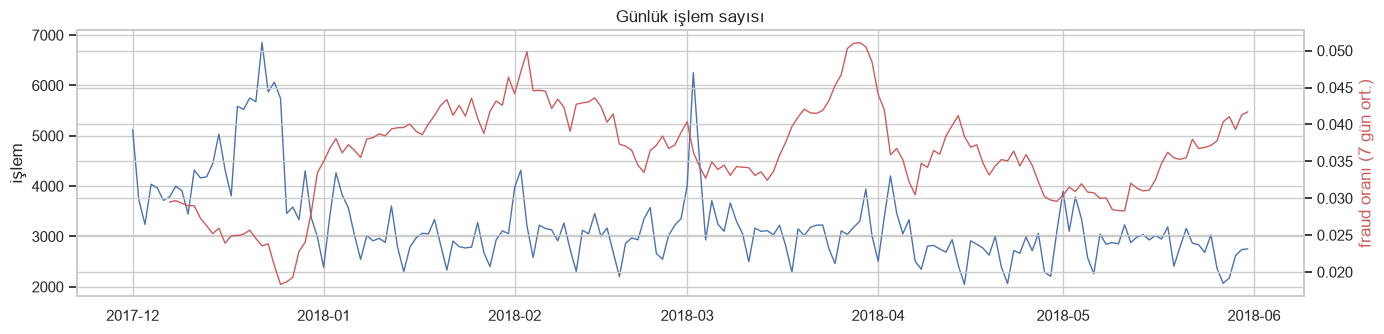

In [3]:
dt = profiler.datetime(df)
print("tarih aralığı:", dt.min(), "->", dt.max(), f"({(dt.max() - dt.min()).days} gün)")

daily = temporal_profile(df, dt, TARGET)["daily_volume"]
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(daily.index, daily["count"], lw=1)
ax.set(title="Günlük işlem sayısı", ylabel="işlem")
ax2 = ax.twinx()
ax2.plot(daily.index, daily["rate"].rolling(7).mean(), color="indianred", lw=1)
ax2.set_ylabel("fraud oranı (7 gün ort.)", color="indianred")
plt.tight_layout()
fig.savefig(IMG / "02_daily_volume.png", dpi=120)

> **Yorum:** TransactionDT gerçek bir tarih değil, bir referans andan geçen saniye. Toplulukta kullanılan 2017-11-30 varsayımıyla veri
> 2017-12-01 ile 2018-05-31 arasını (181 gün) kapsıyor. Bu varsayımı veriyle de kontrol ettim: en yoğun 4 günün 3'ü 22-24 Aralık
> (Noel öncesi alışveriş), hafta içinde ise Cumartesi ve Pazar en düşük hacimli günler. Aylık fraud oranı sabit değil (Aralık %2,6,
> Ocak-Mart %4,0); bu yüzden değerlendirmede rastgele değil zaman bazlı bölme kullandım.

## 2. Null ratio analizi

Adım 1'de boş oranlarını gördük. Burada soru: boş olmak fraud ile ilişkili mi?
`lift_null = fraud oranı (boşken) / fraud oranı (doluyken)`. 1'den uzaklaştıkça boşluk bir sinyaldir.

In [4]:
features = [c for c in df.columns if c != TARGET]
ns = profiler.null_signal(df, features)
ns["log_lift"] = np.log2(ns["lift_null"])

# aynı boşluk bloğundaki kolonlar aynı satırı verir; ailesine göre tekilleştirip göster
fam = ns.index.str.replace(r"\d+$", "", regex=True)
show = ns.assign(family=fam).sort_values("log_lift", key=abs, ascending=False)
show.drop_duplicates(subset=["null_ratio", "lift_null"]).head(15).round(3)

,null_ratio,fraud_rate_null,fraud_rate_present,lift_null,log_lift,family
D7,0.934,0.027,0.149,0.181,-2.464,D
addr1,0.111,0.118,0.025,4.785,2.259,addr
V304,0.000,0.167,0.035,4.764,2.252,V
D12,0.890,0.025,0.117,0.212,-2.240,D
D14,0.895,0.025,0.116,0.219,-2.188,D
D13,0.895,0.026,0.110,0.237,-2.077,D
D6,0.876,0.025,0.105,0.237,-2.075,D
D9,0.873,0.025,0.104,0.238,-2.069,D
id_03,0.888,0.026,0.107,0.241,-2.052,id_
R_emaildomain,0.768,0.021,0.082,0.255,-1.974,R_emaildomain


güçlü boşluk sinyali (lift >= 2 veya <= 0.5) olan kolon sayısı: 211


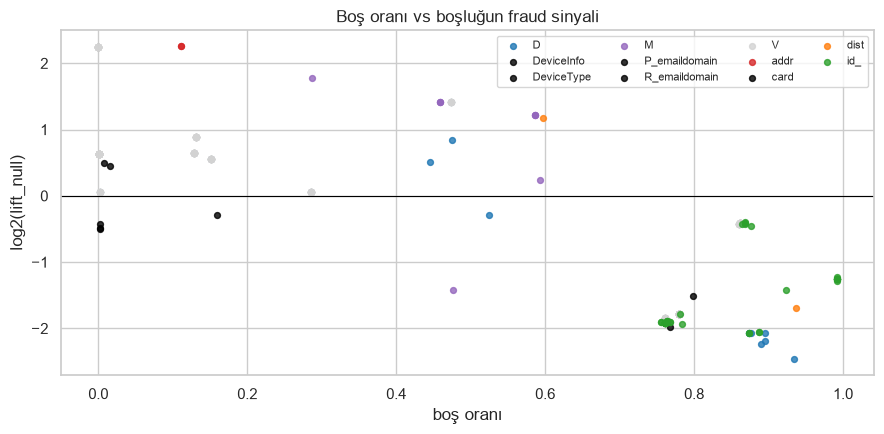

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"V": "lightgray", "D": "tab:blue", "id_": "tab:green", "M": "tab:purple", "addr": "tab:red", "dist": "tab:orange"}
for f, g in ns.assign(family=fam).groupby("family"):
    ax.scatter(g["null_ratio"], g["log_lift"], s=18, label=f, color=colors.get(f, "black"), alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Boş oranı vs boşluğun fraud sinyali", xlabel="boş oranı", ylabel="log2(lift_null)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
fig.savefig(IMG / "02_null_signal.png", dpi=120)

print("güçlü boşluk sinyali (lift >= 2 veya <= 0.5) olan kolon sayısı:", len(profile["null_signal_columns"]))

> **Yorum:** Boş olmak birçok kolonda fraud ile güçlü ilişkili: 211 kolonda lift 2'nin üstünde veya 0,5'in altında. addr1 boşken fraud
> %11,8, doluyken %2,5 (4,8 kat). M kolonlarında da boşluk riski artırıyor (M6 3,4 kat, M1-M3 2,7 kat, M7-M9 2,3 kat), M4'te
> ise tersine (0,37). D ve id_ kolonlarında ilişki ters: boşken fraud daha düşük (lift ~0,2-0,25), yani bu kolonların dolu olduğu
> identity'li ve mobil işlemler daha riskli. Bu yüzden boşluğu doldurup kaybetmek yerine bayrak olarak feature'a çevirdim.

## 3. Outlier analizi

İki yöntem: IQR (Q1 - 1,5*IQR, Q3 + 1,5*IQR) ve robust z (medyan / MAD, eşik 3,5).
Çarpık verilerde IQR çok fazla değeri aykırı sayar; robust z daha seçicidir. Bu fonksiyonlar Adım 4'teki column dedektörünün temeli.

In [6]:
num = schema.of_type("numeric")
ot = profiler.outliers(df, num)
print(f"medyan aykırı oranı  IQR: {ot['iqr_ratio'].median():.3f}   robust z: {ot['robust_z_ratio'].median():.3f}")
ot.loc[[AMT, "C1", "C13", "D1", "D15", "dist1"]].round(3)

medyan aykırı oranı  IQR: 0.101   robust z: 0.037


,iqr_ratio,robust_z_ratio,fraud_rate_outlier,lift_outlier
column,,,,
TransactionAmt,0.113,0.101,0.051,1.468
C1,0.101,0.042,0.058,1.645
C13,0.128,0.235,0.021,0.601
D1,0.126,0.431,0.019,0.534
D15,0.000,0.245,0.014,0.412
dist1,0.168,0.184,0.030,0.864


In [7]:
# aykırı değerlerinde fraud en çok yoğunlaşan kolonlar
ot.sort_values("lift_outlier", ascending=False).head(10).round(3)

,iqr_ratio,robust_z_ratio,fraud_rate_outlier,lift_outlier
column,,,,
V154,0.005,0.005,0.981,28.046
V153,0.004,0.004,0.976,27.883
V148,0.006,0.006,0.959,27.401
V149,0.008,0.008,0.957,27.364
V156,0.008,0.008,0.953,27.247
V155,0.006,0.006,0.944,26.992
V250,0.241,0.002,0.796,22.758
V251,0.244,0.003,0.790,22.574
V256,0.246,0.005,0.768,21.963


> **Yorum:** Medyan kolonda IQR işlemlerin %10,1'ini, robust z %3,7'sini aykırı sayıyor. Veri çarpık olduğu için IQR çok fazla değeri
> aykırı işaretliyor; column dedektöründe robust z'yi seçtim. Bazı kolonlarda MAD 0 çıkıyor (değerlerin yarısından fazlası
> aynı), orada ortalama mutlak sapmaya düşen bir koruma ekledim. Aykırılık her zaman risk demek değil: V148-V156'nın aykırı
> değerlerinde fraud %95-98, ama D1 (kart yaşı) aykırılarında fraud ortalamanın yarısı (lift 0,53), çünkü uç D1 eski kart demek.

## 4. Distribution analizi

Sayısal kolonların çarpıklığı Adım 1'de incelendi (`log_candidates`). Burada zaman boyutu: saat ve haftanın günü.
Saat dilimi bilinmediği için saat görelidir.

log dönüşüm adayı: 322 / 375


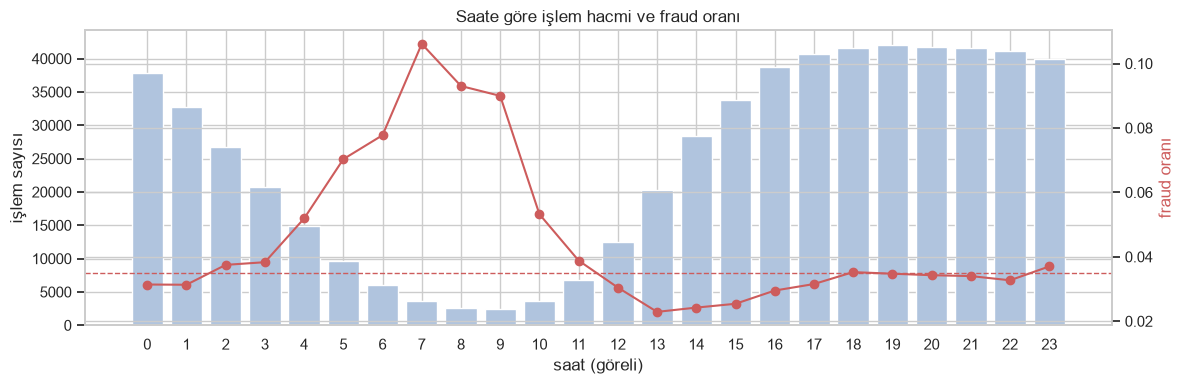

In [8]:
print("log dönüşüm adayı:", len(profile["log_candidates"]), "/", len(num))

tp = temporal_profile(df, dt, TARGET)
hour = tp["hour"]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour.index, hour["count"], color="lightsteelblue", label="işlem sayısı")
ax.set(xlabel="saat (göreli)", ylabel="işlem sayısı", xticks=range(24))
ax2 = ax.twinx()
ax2.plot(hour.index, hour["rate"], color="indianred", marker="o", label="fraud oranı")
ax2.axhline(BASE_RATE, color="indianred", ls="--", lw=1)
ax2.set_ylabel("fraud oranı", color="indianred")
ax.set_title("Saate göre işlem hacmi ve fraud oranı")
plt.tight_layout()
fig.savefig(IMG / "02_hourly_profile.png", dpi=120)

In [9]:
hour[["count", "rate", "lift"]].round(3).T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
count,37795.000,32797.000,26732.000,20802.000,14839.000,9701.000,6007.000,3704.000,2591.000,2479.000,3627.000,6827.000,12451.00,20315.000,28328.000,33859.000,38698.000,40723.000,41639.000,42115.000,41782.000,41641.000,41139.000,39949.000
rate,0.031,0.031,0.037,0.038,0.052,0.070,0.078,0.106,0.093,0.090,0.053,0.039,0.03,0.023,0.024,0.025,0.030,0.032,0.035,0.035,0.034,0.034,0.033,0.037
lift,0.897,0.895,1.071,1.095,1.483,2.009,2.222,3.032,2.658,2.571,1.521,1.109,0.87,0.654,0.692,0.726,0.843,0.901,1.007,0.993,0.980,0.972,0.934,1.057


In [10]:
dow = tp["day_of_week"]
dow.index = dow.index.map(dict(enumerate(["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"])))
dow[["count", "rate", "lift"]].round(4).T

day_of_week,Pzt,Sal,Çar,Per,Cum,Cmt,Paz
count,85433.0000,84815.0000,85356.0000,86377.0000,98502.000,79834.0000,70223.0000
rate,0.0315,0.0330,0.0345,0.0372,0.036,0.0371,0.0356
lift,0.8989,0.9445,0.9864,1.0624,1.030,1.0607,1.0187


> **Yorum:** Saatlere bakınca hacim göreli 05-11 arasında en düşük, fraud oranı ise tam bu saatlerde zirve yapıyor (07'de %10,6, ortalamanın
> 3 katı). E-ticarette hacmin en düşük olduğu saatler gece geç saatleri; bu yüzden TransactionDT'nin UTC olduğunu ve müşterilerin
> ağırlıkla ABD doğu saatinde olduğunu varsayıp 5 saat kaydırdım. Yaygın "gece = 00-05" tanımı bu veride göreli saatle
> tutmuyordu; kaydırmadan sonra gece 00-06 oldu. Günlere göre fraud oranı %3,2 ile %3,7 arasında, neredeyse sabit; hafta sonu
> düzeltmesinin küçük olması gerektiğini burada gördüm (Adım 6'da çarpanı 1,01 çıktı).

## 5. Rare categorical combination analizi

Tek tek sık görülen değerler, birlikte nadir görülebilir. Kombinasyon frekansı tüm verinin %0,05'inden azsa "nadir".

In [11]:
rare = profiler.rare_all(df)
print(f"kolonlar: {rare['columns']}")
print(f"farklı kombinasyon: {rare['n_combinations']}, nadir işlem oranı: {rare['rare_tx_ratio']:.3f}")
print(f"fraud oranı  nadir: {rare['fraud_rate_rare']:.4f}   yaygın: {rare['fraud_rate_common']:.4f}")

kolonlar: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']
farklı kombinasyon: 1734, nadir işlem oranı: 0.076
fraud oranı  nadir: 0.0494   yaygın: 0.0338


In [12]:
profiler.rare_pairs(df).round(4)

,n_combinations,rare_tx_ratio,fraud_rate_rare,fraud_rate_common,lift_rare
pair,,,,,
ProductCD + card4,22,0.0004,0.1058,0.0350,3.0228
ProductCD + card6,18,0.0004,0.0735,0.0350,2.0997
card6 + DeviceType,12,0.0004,0.0541,0.0350,1.5448
card6 + P_emaildomain,167,0.0142,0.0398,0.0349,1.1379
card4 + P_emaildomain,238,0.0172,0.0389,0.0349,1.1108
card4 + DeviceType,15,0.0008,0.0382,0.0350,1.0922
ProductCD + P_emaildomain,196,0.0169,0.0338,0.0350,0.9665
card4 + card6,15,0.0004,0.0338,0.0350,0.9665
P_emaildomain + DeviceType,177,0.0157,0.0335,0.0350,0.9567


> **Yorum:** 5 kategorik kolonun (ürün, kart markası, kart tipi, e-posta, cihaz tipi) 1.734 farklı kombinasyonu var. İşlemlerin %7,6'sı
> nadir bir kombinasyonda; bunlarda fraud %4,9, yaygınlarda %3,4. Sinyal var ama orta düzeyde, tek başına kural olacak kadar
> güçlü değil; bu yüzden nadirliği (combo_rarity) dedektörlere giren bir feature yaptım. İkili kombinasyonlarda ProductCD+card4
> nadir çiftleri 3 kat riskli ama işlemlerin sadece %0,04'ü.

## 6. Kolon ilişkileri

- Sayısal–sayısal: |r| > 0,95 olan kolonlar gruplandı, her gruptan bir temsilci (en az boş, en çok farklı değer) seçildi.
- Kategorik–kategorik: Cramér's V.
- Kolon–hedef: her sayısal kolonun tek başına fraud'u ayırma gücü, `max(AUC, 1-AUC)`.

In [13]:
groups = profile["correlated_groups"]
print(f"sayısal kolon: {len(num)} -> temsilci: {len(profile['numeric_representatives'])} ({len(groups)} çok üyeli grup)")
print("en büyük gruplar:")
for g in sorted(groups, key=len, reverse=True)[:6]:
    print(f"  {g[0]:6s} <- {len(g) - 1} kolon: {', '.join(g[1:8])}{' ...' if len(g) > 8 else ''}")
print("V dışı gruplar:", [g for g in groups if not g[0].startswith("V")])

sayısal kolon: 375 -> temsilci: 260 (61 çok üyeli grup)
en büyük gruplar:
  V307   <- 20 kolon: V308, V317, V318, V294, V280, V295, V127 ...
  V306   <- 15 kolon: V316, V279, V293, V126, V132, V95, V101 ...
  C1     <- 6 kolon: C2, C11, C6, C10, C8, C4
  V298   <- 5 kolon: V299, V105, V296, V329, V330
  V134   <- 3 kolon: V102, V97, V103
  V215   <- 3 kolon: V277, V278, V276
V dışı gruplar: [['C1', 'C2', 'C11', 'C6', 'C10', 'C8', 'C4'], ['C12', 'C7'], ['D1', 'D2'], ['D4', 'D6', 'D12'], ['D5', 'D7']]


id_22      id_26         1.000
id_13      DeviceType    0.821
id_15      DeviceType    0.732
id_30      DeviceType    0.710
           id_32         0.692
ProductCD  DeviceType    0.688
id_32      DeviceType    0.688
id_23      id_26         0.681
dtype: float64

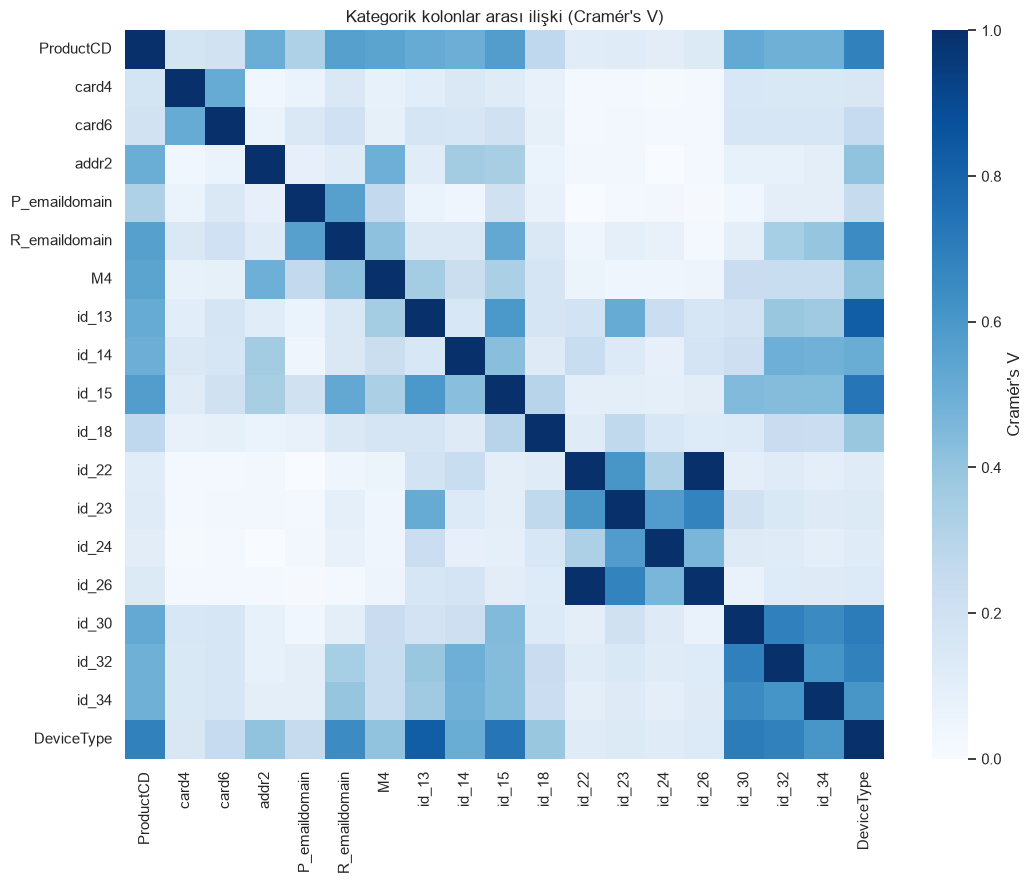

In [14]:
cat = [c.name for c in schema.columns.values() if c.cardinality in ("low", "medium")]
cat += ["ProductCD", "card4", "card6", "DeviceType", "P_emaildomain", "R_emaildomain"]
cat = list(dict.fromkeys(cat))
cv = cramers_v_matrix(profiler.sample(df), cat)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cv, cmap="Blues", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Cramér's V"})
ax.set_title("Kategorik kolonlar arası ilişki (Cramér's V)")
plt.tight_layout()
fig.savefig(IMG / "02_cramers_v.png", dpi=120)

pairs = cv.where(np.triu(np.ones(cv.shape, bool), 1)).stack().sort_values(ascending=False)
pairs.head(8).round(3)

AUC > 0.60 olan sayısal kolon: 138 / 375


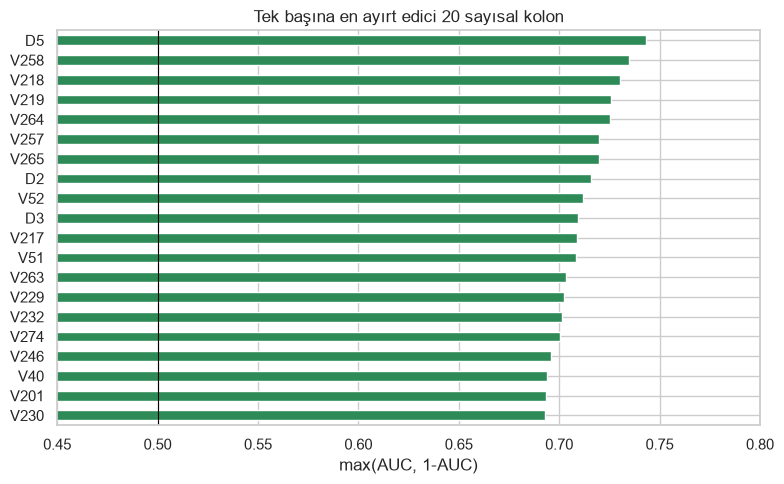

In [15]:
auc = profiler.signal(df, num)
print(f"AUC > 0.60 olan sayısal kolon: {(auc > 0.6).sum()} / {len(auc)}")

fig, ax = plt.subplots(figsize=(8, 5))
auc.head(20).sort_values().plot.barh(ax=ax, color="seagreen")
ax.axvline(0.5, color="black", lw=0.8)
ax.set(title="Tek başına en ayırt edici 20 sayısal kolon", xlabel="max(AUC, 1-AUC)", xlim=(0.45, 0.8))
plt.tight_layout()
fig.savefig(IMG / "02_univariate_auc.png", dpi=120)

> **Yorum:** Sayısal kolonların çoğu birbirinin kopyası gibi: |r| > 0,95 eşiğiyle 375 kolon 260 temsilciye iniyor. C1, C2, C4, C6, C8,
> C10, C11 tek grup, D1 ile D2 aynı bilgi. Multivariate modele sadece temsilcileri verdim; aynı bilgiyi 7 kez vermek Isolation
> Forest'ın o yönde daha sık bölmesine yol açardı. Kategoriklerde id_22 ile id_26 aynı bilgiyi taşıyor (Cramér's V = 1).
> Tek kolonların ayırma gücünde en iyisi D5 (AUC 0,743); 138 kolonun AUC'si 0,6'nın üstünde ama hiçbiri tek başına yeterli
> değil. Birden fazla katmanı birleştiren yaklaşımın gerekçesi bu.

## 7. Entity davranış pattern'leri

Veride kullanıcı kolonu yok, bir sözde kullanıcı (uid) tanımlamak gerekiyor. `D1` kartın ilk kullanımından beri geçen gün olarak yorumlanıyor;
`işlem günü - D1` (D1n) aynı kart için sabit bir "başlangıç günü" verir.

Adaylar karşılaştırılıyor. `purity_fraud`: fraud işlemlerin, çoğunluğu fraud olan bir entity içinde bulunma oranı. Yüksekse tanım gerçek bir kişiyi yakalıyor demek
(etiket sadece tanımı değerlendirmek için kullanılıyor).

In [16]:
df["D1n"] = df[TIME] // 86400 - df["D1"]

# D1n gerçekten kart başına sabit mi? card1+addr1 grubunda kaç farklı D1n var
g = df.dropna(subset=["D1"]).groupby(["card1", "addr1"])["D1n"].nunique()
print(f"card1+addr1 başına farklı D1n sayısı  medyan: {g.median():.0f}   %90: {g.quantile(.9):.0f}")

candidates = {
    "card1": ["card1"],
    "card1+addr1": ["card1", "addr1"],
    "card1+addr1+D1n": ["card1", "addr1", "D1n"],
    "card1+addr1+D1n+P_email": ["card1", "addr1", "D1n", "P_emaildomain"],
}
compare_entity_keys(df, candidates, TARGET).round(3)

card1+addr1 başına farklı D1n sayısı  medyan: 1   %90: 10


,n_entity,median_tx_per_entity,single_tx_entity_ratio,tx_with_history_ratio,purity_fraud,mixed_entity_ratio
uid,,,,,,
card1,13553,4.0,0.254,0.994,0.055,0.113
card1+addr1,39974,2.0,0.394,0.973,0.162,0.067
card1+addr1+D1n,217850,1.0,0.575,0.788,0.761,0.014
card1+addr1+D1n+P_email,273919,1.0,0.648,0.699,0.869,0.008


işlem  fraud_oranı
işlem_sayısı 1      125222       0.0241
             11-50  143062       0.0421
             2       72106       0.0307
             3-5    124679       0.0341
             50+     17385       0.0710
             6-10   108086       0.0363
cihaz_sayısı 0      425125       0.0220
             1       97715       0.0579
             2       26782       0.0745
             3+      40918       0.0891

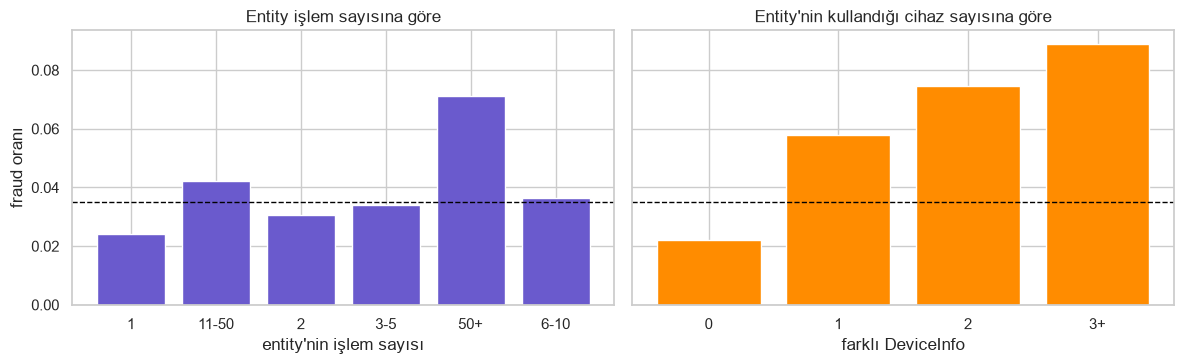

In [17]:
# davranış analizi için card1+addr1+D1n kullanıldı (karar notes.md'de)
key = combination_key(df, ["card1", "addr1", "D1n"])
ent = entity_profile(df, key, TARGET, AMT, {
    "n_devices": ("DeviceInfo", "nunique"),
    "n_emails": ("P_emaildomain", "nunique"),
})

tx_bins = pd.cut(ent["n_tx"], [0, 1, 2, 5, 10, 50, np.inf], labels=["1", "2", "3-5", "6-10", "11-50", "50+"])
dev_bins = pd.cut(ent["n_devices"], [-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"])
by_tx = df.groupby(tx_bins.reindex(key.to_numpy()).to_numpy(), observed=True)[TARGET].agg(işlem="size", fraud_oranı="mean")
by_dev = df.groupby(dev_bins.reindex(key.to_numpy()).to_numpy(), observed=True)[TARGET].agg(işlem="size", fraud_oranı="mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
axes[0].bar(by_tx.index.astype(object).astype(str), by_tx["fraud_oranı"], color="slateblue")
axes[0].set(title="Entity işlem sayısına göre", xlabel="entity'nin işlem sayısı", ylabel="fraud oranı")
axes[1].bar(by_dev.index.astype(object).astype(str), by_dev["fraud_oranı"], color="darkorange")
axes[1].set(title="Entity'nin kullandığı cihaz sayısına göre", xlabel="farklı DeviceInfo")
for ax in axes:
    ax.axhline(BASE_RATE, color="black", ls="--", lw=1)
plt.tight_layout()
fig.savefig(IMG / "02_entity_behavior.png", dpi=120)
pd.concat({"işlem_sayısı": by_tx, "cihaz_sayısı": by_dev}).round(4)

> **Yorum:** Veride kullanıcı kolonu yok, o yüzden bir sözde kullanıcı tanımlamam gerekti. card1 tek başına kişi değil (13.553 değer,
> purity 0,055). İşlem günü - D1 kart başına sabit bir başlangıç günü veriyor; aynı card1+addr1 grubunda medyan 1 farklı değer
> alması bu yorumu destekliyor. card1+addr1+D1n ile purity 0,761'e çıkıyor ve işlemlerin %78,8'inin hâlâ geçmişi var.
> P_emaildomain eklemek purity'yi 0,869'a çıkarıyor ama geçmişli işlem %69,9'a iniyor ve e-posta %16 boş; eklemedim.
> Davranışta önemli bir bulgu: 50'den fazla işlemi olan entity'lerde fraud %7,1, tek işlemlilerde %2,4. Yani "çok işlem yapan
> güvenilirdir" varsayımı bu veride ters; Adım 6'da güvenilir kullanıcıyı işlem sayısına değil kart yaşına ve bilinen cihaza
> dayandırdım. 3 ve daha fazla cihaz kullanan entity'lerde fraud %8,9, cihaz bilgisi olmayanlarda %2,2.

## 8. Özet

Üretilen çıktılar: `artifacts/profile.json` (korelasyon grupları, temsilci kolonlar, boşluk sinyali, log adayları, saatlik profil), `docs/images/02_*.png`

Bulgular ve Adım 3-4'e etkisi

- uid = card1 + addr1 + D1n (purity 0,761, geçmişli işlem %78,8). Zayıf yanı: C/H/R ürünlerinde D1 çoğunlukla 0, bu ürünlerde geçmiş parçalanıyor.
- Saat: TransactionDT UTC varsayımıyla -5 saat kaydırma; gece 00-06, iş saati 09-18.
- Boşluk bayrakları: addr1, dist1, R_emaildomain ve M bloklarının (M1, M4, M6, M7) her biri için bir bayrak + satırdaki toplam boş sayısı.
- Multivariate girdisi: 260 temsilci sayısal kolon + Adım 3 feature'ları; aykırılık için robust z.
- Tutmayan varsayımlar: "çok işlem yapan güvenilirdir" ve "gece = 00-05" bu veride tutmadı.